In [98]:
import pandas as pd
import matplotlib.pyplot as plt 
%matplotlib inline

## Load dataset, Iris of flowers

In [99]:
import pandas as pd
from sklearn.datasets import load_iris
iris = load_iris()
dataset = pd.DataFrame(iris['data'], columns = iris['feature_names'])
dataset


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


For simplicity and visulaise reseaon, we drop the `sepal width` and `sepal length` features

In [100]:
dataset.drop(['sepal width (cm)','sepal length (cm)'], axis = 1 , inplace = True)
dataset.head()

,petal length (cm),petal width (cm)
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2


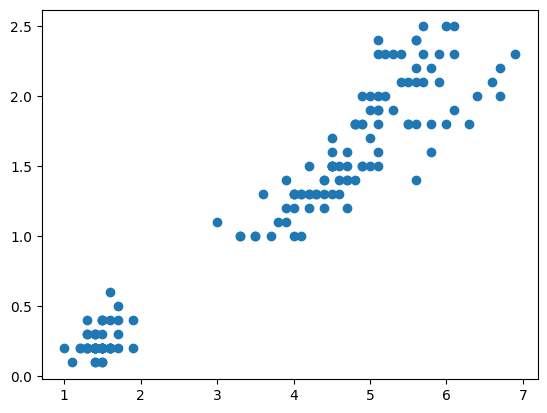

In [101]:
plt.scatter(dataset.iloc[:,0], dataset.iloc[:,1])

We make the dataset between 0 and 1 using min max scaler 

In [102]:
from sklearn.preprocessing import MinMaxScaler
minmax = MinMaxScaler()
minmax.fit(dataset[['petal length (cm)']])
dataset['petal length (cm)'] = minmax.transform(dataset[['petal length (cm)']])

minmax.fit(dataset[['petal width (cm)']])
dataset['petal width (cm)'] = minmax.transform(dataset[['petal width (cm)']])

dataset


,petal length (cm),petal width (cm)
0,0.067797,0.041667
1,0.067797,0.041667
2,0.050847,0.041667
3,0.084746,0.041667
4,0.067797,0.041667
...,...,...
145,0.711864,0.916667
146,0.677966,0.750000
147,0.711864,0.791667
148,0.745763,0.916667


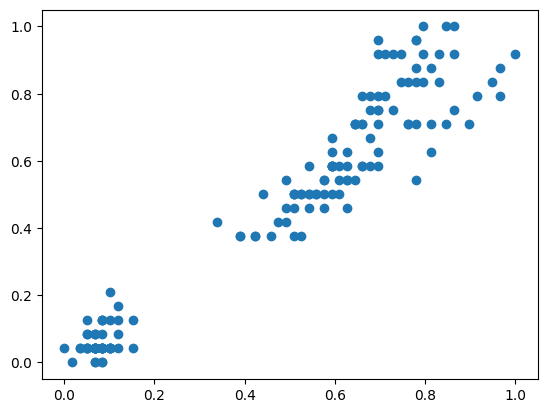

In [103]:
plt.scatter(dataset.iloc[:,0], dataset.iloc[:,1])

In [104]:
from sklearn.cluster import KMeans
km = KMeans(n_clusters=2)

we choose `k = 2` for this case, you can choose `3` if you want

In [105]:
y_predicted = km.fit_predict(dataset)
km.cluster_centers_

array([[0.07830508, 0.06083333],
       [0.6620339 , 0.65666667]])

In [106]:
dataset['cluster'] = y_predicted
dataset

,petal length (cm),petal width (cm),cluster
0,0.067797,0.041667,0
1,0.067797,0.041667,0
2,0.050847,0.041667,0
3,0.084746,0.041667,0
4,0.067797,0.041667,0
...,...,...,...
145,0.711864,0.916667,1
146,0.677966,0.750000,1
147,0.711864,0.791667,1
148,0.745763,0.916667,1


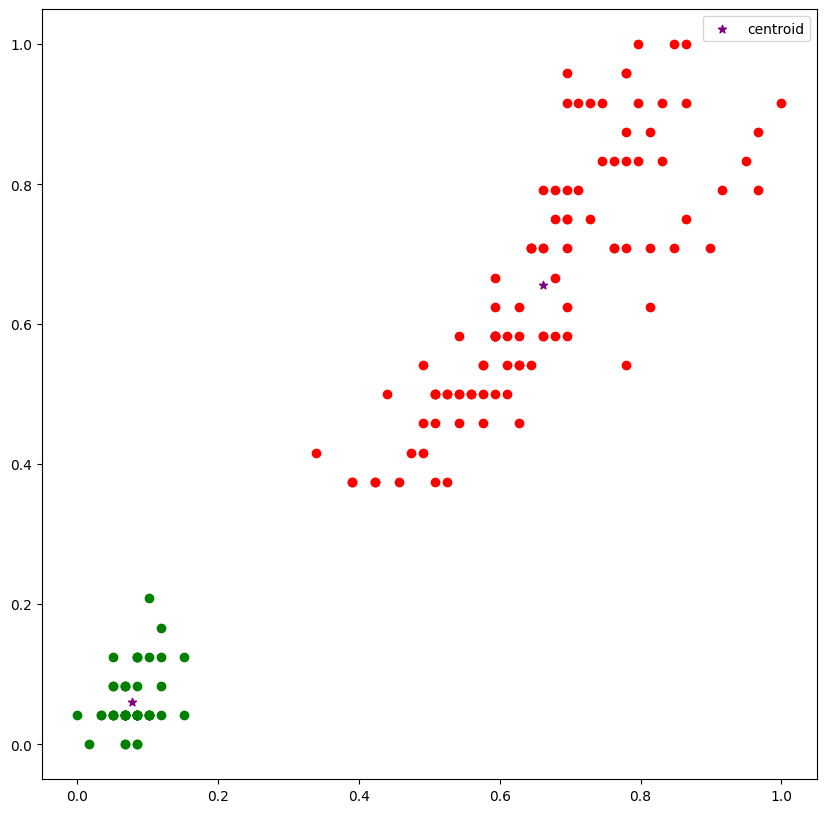

In [107]:
df1 = dataset[dataset.cluster == 0]
df2 = dataset[dataset.cluster == 1]
plt.figure(figsize = (10,10))
plt.scatter(df1.iloc[:,0], df1.iloc[:,1], color = 'green')
plt.scatter(df2.iloc[:,0], df2.iloc[:,1], color = 'red')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='*',label='centroid')
plt.legend()
plt.show()

from the figure, we can see the 2 clusters with their certroids denoted with `*`

## Elbow method graph

In [108]:
sse = [] # sum of squared error
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k)
    km.fit(dataset)
    sse.append(km.inertia_)

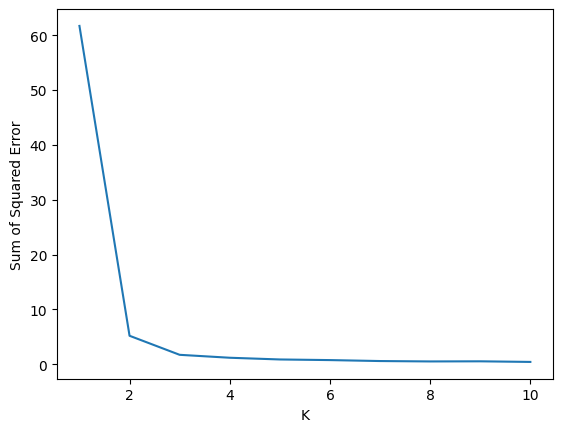

In [109]:
plt.xlabel('K')
plt.ylabel('Sum of Squared Error')
plt.plot(k_range, sse)

From the figure, it is clear that k = 2 is a good choice (using Elbow method)